# <font size=7> 6장 추세 추종 전략</font>

# 6.1 이동 평균선 교차 전략

## Event-Driven Backtest

### 코드 6-1 애플 주가 다운로드

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

ticker = 'AAPL'
start_date = '2022-08-01'
end_date = '2024-08-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


### 코드 6-2 이동평균선 교차 전략의 Event-Driven Backtest1

In [2]:
short_window = 10 # 단기
long_window = 20 # 장기

# 지수가중 이동평균선 계산
data = df.copy()
data['Short_MA'] = data['Close'].ewm(span=short_window, adjust=False).mean()
data['Long_MA'] = data['Close'].ewm(span=long_window, adjust=False).mean()
data = data[long_window:].copy() # 초기 데이터 제거

cash_init = 10000 # 초기 현금
cash = cash_init
asset = [cash] # 보유 자산 가치 기록 리스트
pos = 0 # 1: 포지션(1:매수->주식 보유, 0:현금 보유)

for i in range(1, len(data)):
    if pos == 0:
        if data['Short_MA'].iloc[i] > data['Long_MA'].iloc[i] and \
        data['Short_MA'].iloc[i-1] < data['Long_MA'].iloc[i-1]: # 골든 크로스
            pos = 1 # 포지션 갱신
            entry_price = data['Close'].iloc[i] # 매수 가격
            num = int(cash/entry_price) # 매수 수량
            cash -= entry_price*num # 주식 매수 대금 지급에 따른 현금 갱신
    elif pos == 1:                
        if data['Short_MA'].iloc[i] < data['Long_MA'].iloc[i] and \
        data['Short_MA'].iloc[i-1] > data['Long_MA'].iloc[i-1]: # 데스 크로스
            pos = 0 # 포지션 갱신
            cash += data['Close'].iloc[i]*num # 주식 매도 대금 유입에 따른 현금 갱신

    # 자산 가치 갱신, 기록
    if pos == 0:
        asset.append(cash)
    elif pos == 1:
        asset.append(cash + data['Close'].iloc[i]*num)             

# 누적 수익률 계산, 출력
data['Cumulative_Return'] = np.array(asset)/cash_init
final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
print(f'Final cumulative return of the strategy: {100*final_cum_return:.2f}%')    

Final cumulative return of the strategy: 29.38%


### 코드 6-4 이동평균선 교차 전략의 Event-Driven Backtest2

In [3]:
short_window = 10 # 단기
long_window = 20 # 장기

# 지수가중 이동평균선 계산
data = df.copy()
data['Short_MA'] = data['Close'].ewm(span=short_window, adjust=False).mean()
data['Long_MA'] = data['Close'].ewm(span=long_window, adjust=False).mean()
data = data[long_window:].copy() # 초기 데이터 제거

# 포지션과 시그널 계산
data['Position'] = np.where(data['Short_MA'] > data['Long_MA'], 1, 0)
data['Signal'] = data['Position'].diff().fillna(0) # 1: 매수, -1: 매도

cash_init = 10000 # 초기 현금
cash = cash_init
asset = np.zeros(len(data)) # 보유 자산 가치 기록 배열
asset[0] = cash
pos = 0 # 1: 포지션(1:매수->주식 보유, 0:현금 보유)

prices = data['Close'].values # 종가 넘파이 배열
signals = data['Signal'].values # 시그널 넘파이 배열

for i in range(1, len(data)):
    if pos == 0:
        if signals[i] == 1: # 골든 크로스
            pos = 1 # 포지션 갱신
            entry_price = prices[i] # 매수 가격
            num = int(cash/entry_price) # 매수 수량
            cash -= entry_price*num # 주식 매수 대금 지급에 따른 현금 갱신
    elif pos == 1:                
        if signals[i] == -1: # 데스 크로스
            pos = 0 # 포지션 갱신
            cash += prices[i]*num # 주식 매도 대금 유입에 따른 현금 갱신

    # 자산 가치 갱신, 기록
    if pos == 0:
        asset[i] = cash
    elif pos == 1:
        asset[i] = cash + prices[i]*num     

# 시각화를 위한 매수, 매도 시점과 가격 컬럼 계산
data['Buy_Price'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
data['Sell_Price'] = np.where(data['Signal'] == -1, data['Close'], np.nan)

# 누적 수익률 계산, 출력
data['Cumulative_Return'] = np.array(asset)/cash_init
final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
print(f'Final cumulative return of the strategy: {100*final_cum_return:.2f}%')   

Final cumulative return of the strategy: 29.38%


### 코드 6-5 이동평균선 교차 전략에 따른 매매와 포지션 시각화

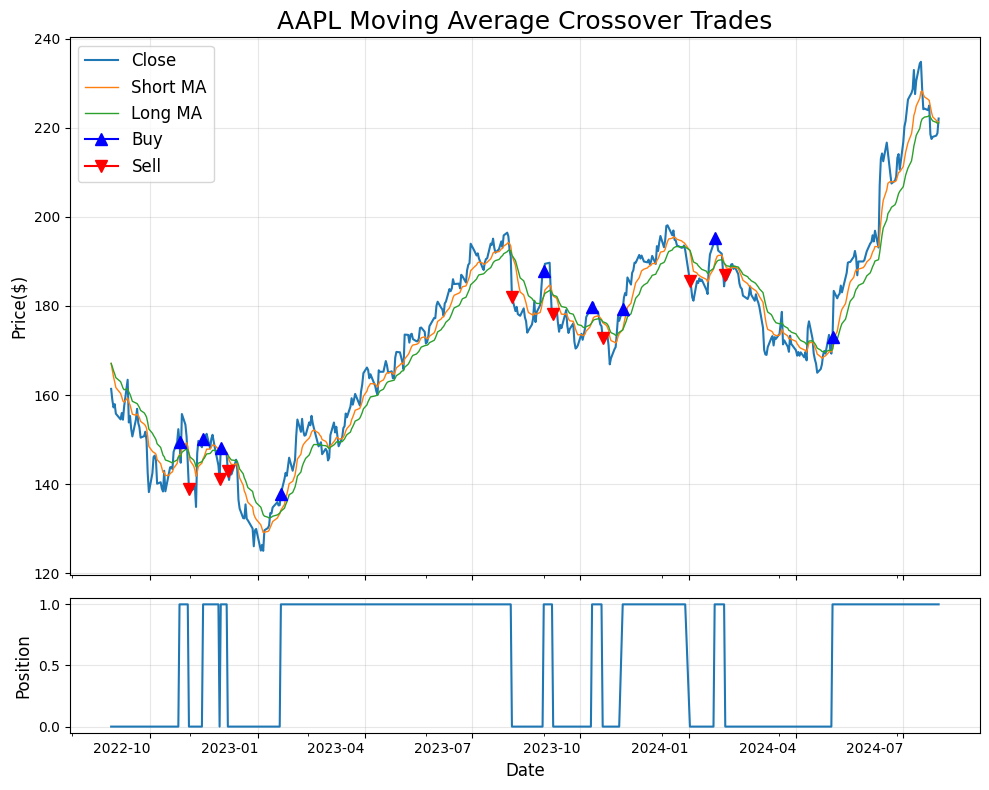

In [4]:
fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=(8,2), figsize=(10,8))

data['Close'].plot(ax=ax[0], label='Close')
data['Short_MA'].plot(ax=ax[0], label='Short MA', linewidth=1)
data['Long_MA'].plot(ax=ax[0], label='Long MA', linewidth=1)
data['Buy_Price'].plot(ax=ax[0], label='Buy', marker='^', color='b', markersize=8)
data['Sell_Price'].plot(ax=ax[0], label='Sell', marker='v', color='r', markersize=8)

ax[0].set_title(f'{ticker} Moving Average Crossover Trades', fontsize=18)
ax[0].set_ylabel('Price($)', fontsize=12)
ax[0].legend(fontsize=12)
ax[0].grid(alpha=0.3)

data['Position'].plot(ax=ax[1])
ax[1].set_xlabel('Date', fontsize=12)
ax[1].set_ylabel('Position', fontsize=12)
ax[1].grid(alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
start_date = '2010-03-02'
end_date = '2010-03-10'

dt_index = pd.date_range(start=start_date, end=end_date)

print(dt_index)

DatetimeIndex(['2010-03-02', '2010-03-03', '2010-03-04', '2010-03-05',
               '2010-03-06', '2010-03-07', '2010-03-08', '2010-03-09',
               '2010-03-10'],
              dtype='datetime64[ns]', freq='D')


In [6]:
pos_df = pd.DataFrame({'Position':[0,0,0,1,1,1,0,0,0]}, index=dt_index)
pos_df['Signal'] = pos_df['Position'].diff()
pos_df.index.name = 'Date'
pos_df

,Position,Signal
Date,,
2010-03-02,0,NaN
2010-03-03,0,0.0
2010-03-04,0,0.0
2010-03-05,1,1.0
2010-03-06,1,0.0
2010-03-07,1,0.0
2010-03-08,0,-1.0
2010-03-09,0,0.0
2010-03-10,0,0.0


## Vectorized Backtest

In [7]:
ticker = 'AAPL'
start_date = '2022-08-01'
end_date = '2024-08-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


### 코드 6-6 이동평균선 교차 전략 Vectorized Backtest

In [8]:
short_window = 10
long_window = 20
data = df.copy()
data['Short_MA'] = data['Close'].ewm(span=short_window, adjust=False).mean()
data['Long_MA'] = data['Close'].ewm(span=long_window, adjust=False).mean()
data = data[long_window:].copy()

positions = pd.Series(np.where(data['Short_MA'] > data['Long_MA'], 1, 0), \
                      index=data.index)
signals = positions.diff().fillna(0)

data['Position'] = np.nan
data.loc[signals == 1, 'Position'] = 1
data.loc[signals == -1, 'Position'] = 0
data['Position'] = data['Position'].ffill()
data['Position'] = data['Position'].replace(np.nan, 0)

data['Signal'] = data['Position'].diff().fillna(0)

data['Buy_Price'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
data['Sell_Price'] = np.where(data['Signal'] == -1, data['Close'], np.nan)   

data['Daily_Return'] = np.where(data['Position'].shift()==1, \
                                data['Close'].pct_change(), 0)
data['Cumulative_Return'] = (1+data['Daily_Return']).cumprod()    

final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
print(f'Final cumulative return of the strategy: {100*final_cum_return:.2f}%')

Final cumulative return of the strategy: 29.40%


## 6.1.3 파라미터 최적화

### 코드 6-7 이동평균선 교차 전략 Vectorized Backtest 함수

In [9]:
def mac_strategy1(df, sw, lw):
    short_window = sw
    long_window = lw
    data = df.copy()
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()
    
    positions = pd.Series(np.where(data['Short_MA'] > data['Long_MA'], 1, 0), \
                          index=data.index)
    signals = positions.diff().fillna(0)
    
    data['Position'] = np.nan
    data.loc[signals == 1, 'Position'] = 1
    data.loc[signals == -1, 'Position'] = 0
    data['Position'] = data['Position'].ffill()
    data['Position'] = data['Position'].replace(np.nan, 0)
    
    data['Signal'] = data['Position'].diff().fillna(0)
    
    data['Buy_Price'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
    data['Sell_Price'] = np.where(data['Signal'] == -1, data['Close'], np.nan)   
    
    data['Daily_Return'] = np.where(data['Position'].shift()==1, \
                                    data['Close'].pct_change(), 0)
    data['Cumulative_Return'] = (1+data['Daily_Return']).cumprod()    
    
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    print(f'Final cumulative return of the strategy: '
    f'{100*final_cum_return:.2f}%')    

    return data, final_cum_return

### 코드 6-8 이동평균선 교차 전략 파라미터 최적화

In [10]:
def parameter_optimizer1(input_df):
    short_window = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, \
                    18, 19, 20, 21]
    long_window =[22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, \
                  35, 36, 37, 38, 39, 40, 41, 42]
    ret_list = []  

    for x1, x2, in [(a,b) for a in short_window for b in long_window]:
        df = input_df.copy()
        _, ret = mac_strategy1(df, x1, x2)
        ret_list.append((x1, x2, ret))

    optimal_params = max(ret_list, key=lambda x:x[2])
    optimal_df = pd.DataFrame(ret_list, \
                              columns=['short_window','long_window','ror'])
    print(f'Optimal Parameters:{optimal_params[0], optimal_params[1]}, '
    f'Optimized Return:{100*optimal_params[2]:.2f}%')

    return optimal_params, optimal_df

In [11]:
ticker = 'AAPL'
# start_date = '2019-01-01'
start_date = '2022-08-01'
# end_date = '2024-01-01'
end_date = '2024-08-01'

df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


In [12]:
optimal_params, optimal_df = parameter_optimizer1(df)

Final cumulative return of the strategy: 20.46%
Final cumulative return of the strategy: 20.46%
Final cumulative return of the strategy: 21.76%
Final cumulative return of the strategy: 21.92%
Final cumulative return of the strategy: 27.84%
Final cumulative return of the strategy: 28.16%
Final cumulative return of the strategy: 26.84%
Final cumulative return of the strategy: 18.72%
Final cumulative return of the strategy: 12.02%
Final cumulative return of the strategy: 15.04%
Final cumulative return of the strategy: 15.29%
Final cumulative return of the strategy: 17.59%
Final cumulative return of the strategy: 14.70%
Final cumulative return of the strategy: 16.52%
Final cumulative return of the strategy: 16.52%
Final cumulative return of the strategy: 21.68%
Final cumulative return of the strategy: 24.31%
Final cumulative return of the strategy: 25.35%
Final cumulative return of the strategy: 25.20%
Final cumulative return of the strategy: 25.20%
Final cumulative return of the strategy:

In [13]:
optimal_params

(19, 41, np.float64(0.5004423834645593))

In [14]:
optimal_df[optimal_df.ror>0.485]

,short_window,long_window,ror
272,17,42,0.486607
290,18,39,0.486607
291,18,40,0.486607
292,18,41,0.486607
293,18,42,0.486480
310,19,38,0.486607
311,19,39,0.486607
312,19,40,0.486480
313,19,41,0.500442
330,20,37,0.486607


### 코드 6-9 이동평균선 교차 전략 파라미터 최적화 업그레이드

In [15]:
def parameter_optimizer1b(input_df): 
    short_window = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, \
                    18, 19, 20, 21]
    long_window =[22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, \
                  35, 36, 37, 38, 39, 40, 41, 42]
    ret_list = []  

    for x1, x2, in [(a,b) for a in short_window for b in long_window]:
        df = input_df.copy()
        _, ret = mac_strategy1(df, x1, x2)
        ret_list.append((x1, x2, ret))

    max_ror = max(ret_list, key=lambda x:x[2])[2]
    max_tups = [tup for tup in ret_list if tup[2] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    
    optimal_df = pd.DataFrame(ret_list, \
                              columns=['short_window','long_window','ror'])
    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:{opt_param1, opt_param2}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2), optimal_df

In [16]:
optimal_params, optimal_df = parameter_optimizer1b(df)

Final cumulative return of the strategy: 20.46%
Final cumulative return of the strategy: 20.46%
Final cumulative return of the strategy: 21.76%
Final cumulative return of the strategy: 21.92%
Final cumulative return of the strategy: 27.84%
Final cumulative return of the strategy: 28.16%
Final cumulative return of the strategy: 26.84%
Final cumulative return of the strategy: 18.72%
Final cumulative return of the strategy: 12.02%
Final cumulative return of the strategy: 15.04%
Final cumulative return of the strategy: 15.29%
Final cumulative return of the strategy: 17.59%
Final cumulative return of the strategy: 14.70%
Final cumulative return of the strategy: 16.52%
Final cumulative return of the strategy: 16.52%
Final cumulative return of the strategy: 21.68%
Final cumulative return of the strategy: 24.31%
Final cumulative return of the strategy: 25.35%
Final cumulative return of the strategy: 25.20%
Final cumulative return of the strategy: 25.20%
Final cumulative return of the strategy:

In [17]:
optimal_params

(19, 40)

## 6.1.4 전략 성능 지표 Performance Metrics

### 코드 6-10 전략의 성능 지표를 계산하고 출력하는 함수

In [18]:
def tear_sheet1(data):
    
    # 투자기간 Trading Period in Years
    trading_period = len(data)/252 # in year
    print(f'Trading Period:{trading_period:.1f} years')    
    
    # 수익률 Rate of Return
    buy_and_hold = data['Close'].iloc[-1]\
    /data['Close'].iloc[0] - 1
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    print(f'Final cumulative return of the strategy:'
    f'{100*final_cum_return:.2f}%, Buy&Hold:{100*buy_and_hold:.2f}%')
    
    # 연평균 성장률 CAGR   
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold+1)**(1/trading_period)-1
    print(f'Strategy CAGR:{100*CAGR_strategy:.2f}%, '
           f'Benchmark CAGR:{100*CAGR_benchmark:.2f}%')
    
    # 샤프 지수 Sharpe Ratio
    risk_free_rate = 0.003
    strategy_daily_return = data['Cumulative_Return'].pct_change().fillna(0)
    mean_return = strategy_daily_return.mean()*252
    std_return = strategy_daily_return.std()*np.sqrt(252)
    sharpe_ratio = (mean_return - risk_free_rate) / std_return
    print(f'Sharpe Ratio: {sharpe_ratio:.2f}')
    
    # 최대 낙폭 Maximum Drawdown
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    max_drawdown = data['Drawdown'].min()
    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min() 
    print(f'Strategy MDD: {100*max_drawdown:.2f}%, '
          f'Benchmark MDD: {100*mdd_benchmark:.2f}%')   

    # 승률 Win Rate
    buy_signals = data[data['Signal'] == 1].index
    sell_signals = data[data['Signal'] == -1].index
    returns = []
    holding_periods = []
    for buy_date in buy_signals:
        sell_dates = sell_signals[sell_signals > buy_date]
        if not sell_dates.empty:
            sell_date = sell_dates[0]
            buy_price = data.loc[buy_date, 'Close']
            sell_price = data.loc[sell_date, 'Close']
            return_pct = sell_price/buy_price - 1
            returns.append(return_pct)          
            holding_period = np.busday_count(buy_date.date(), sell_date.date())
            holding_periods.append(holding_period)
    profitable_trades = len([r for r in returns if r > 0])
    loss_trades = len([r for r in returns if r <= 0])
    total_trades = len(returns)
    win_rate = profitable_trades / total_trades if total_trades > 0 else 0
    print(f'Number of Profitable Trades:{profitable_trades}, '
    f'Number of Loss Trades:{loss_trades}, Win Rate:{100*win_rate:.2f}%')
    
    # 평균 보유 기간 Average Holding Period
    if holding_periods:
        average_holding_period = np.mean(holding_periods)
    else:
        average_holding_period = 0
    print(f'Average Holding Period:{average_holding_period:.1f}days')

    # 평균 이익과 손실 Average Profit and Loss
    if profitable_trades > 0:
        average_profit = np.mean([r for r in returns if r > 0])
    else:
        average_profit = 0
    
    if loss_trades > 0:
        average_loss = np.mean([r for r in returns if r <= 0])
    else:
        average_loss = 0
    print(f'Avg ROR/trade in profitable trades:{average_profit:.3f}%, '
          f'Avg ROR/trade in loss trades:{average_loss:.3f}%')
    
    # 손익비 Profit/Loss Ratio
    if average_loss != 0:
        profit_loss_ratio = average_profit / abs(average_loss)
    else:
        profit_loss_ratio = np.inf
    
    print(f'Profit/Loss Ratio: {profit_loss_ratio:.2f}')

In [19]:
data, ret = mac_strategy1(df, 19, 40)

Final cumulative return of the strategy: 48.65%


In [20]:
tear_sheet1(data)

Trading Period:1.8 years
Final cumulative return of the strategy:48.65%, Buy&Hold:46.34%
Strategy CAGR:24.08%, Benchmark CAGR:23.03%
Sharpe Ratio: 1.45
Strategy MDD: -12.27%, Benchmark MDD: -19.73%
Number of Profitable Trades:2, Number of Loss Trades:1, Win Rate:66.67%
Average Holding Period:66.7days
Avg ROR/trade in profitable trades:0.131%, Avg ROR/trade in loss trades:-0.035%
Profit/Loss Ratio: 3.78


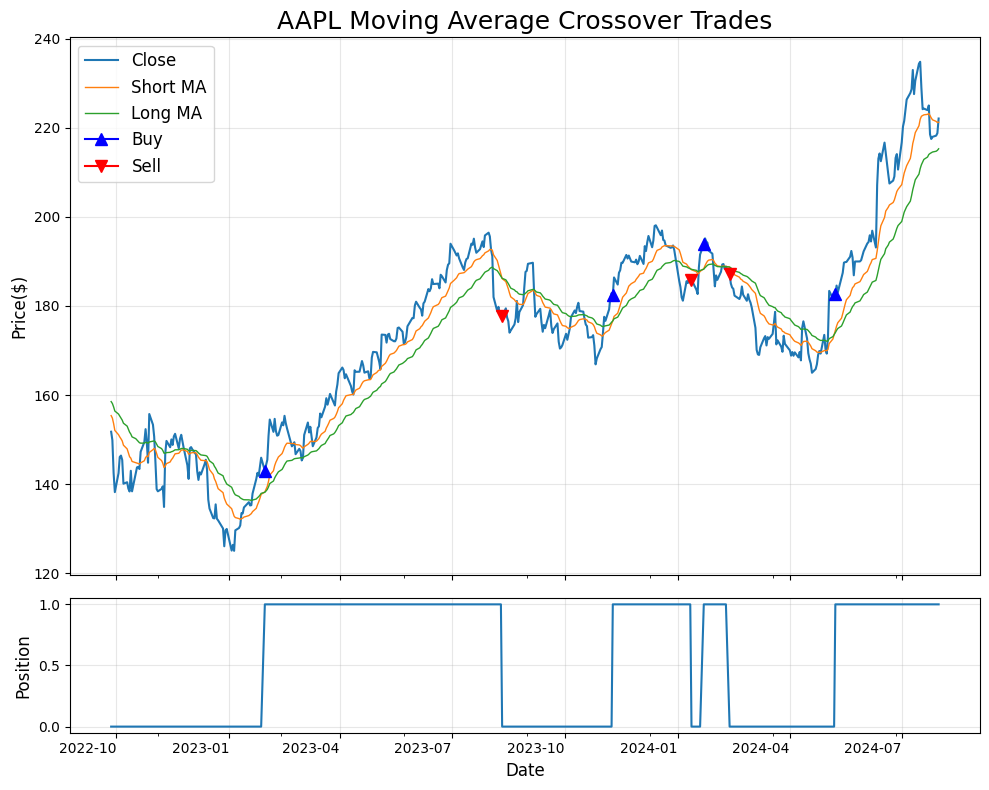

In [21]:
fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=(8,2), figsize=(10,8))

data['Close'].plot(ax=ax[0], label='Close')
data['Short_MA'].plot(ax=ax[0], label='Short MA', linewidth=1)
data['Long_MA'].plot(ax=ax[0], label='Long MA', linewidth=1)
data['Buy_Price'].plot(ax=ax[0], label='Buy', marker='^', color='b', markersize=8)
data['Sell_Price'].plot(ax=ax[0], label='Sell', marker='v', color='r', markersize=8)

ax[0].set_title(f'{ticker} Moving Average Crossover Trades', fontsize=18)
ax[0].set_ylabel('Price($)', fontsize=12)
ax[0].legend(fontsize=12)
ax[0].grid(alpha=0.3)

data['Position'].plot(ax=ax[1])
ax[1].set_xlabel('Date', fontsize=12)
ax[1].set_ylabel('Position', fontsize=12)
ax[1].grid(alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 6.2 손절 추가하기

In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

### 코드 6-11 Trailing Stop 적용한 이동평균선 교차 전략의 Event-Driven Backtest

In [23]:
def mac_strategy2a(df, sw, lw, sl, verbose=True):
    stop_loss = sl   
    short_window = sw
    long_window = lw
    data = df.copy()
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()

    positions = pd.Series(np.where(data['Short_MA'] > data['Long_MA'], 1, 0), \
                          index=data.index)
    signals = positions.diff().fillna(0) # 1: 골든 크로스, -1: 데스 크로스    
    
    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash
    pos = 0 # 1: 포지션(1:매수->주식 보유, 0:현금 보유)
    
    prices = data['Close'].values
    signals = signals.values
    pos_vec = np.zeros(len(data))
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 1: # 골든 크로스 발생
                pos_vec[i] = 1
                pos = 1
                entry_price = prices[i]
                num = int(cash/entry_price)
                cash -= entry_price*num
                stop_loss_price = entry_price*(1 - stop_loss) # 손절가
        elif pos == 1:
            if prices[i] < stop_loss_price: # 손절 발생
                pos = 0
                cash += prices[i]*num
                # cash += stop_loss_price*num                
            elif signals[i] == -1: # 데드 크로스 발생
                pos = 0
                cash += prices[i]*num
            else: # 포지션 유지 -> 손절가 갱신
                pos_vec[i] = 1
                stop_loss_price = max(stop_loss_price, \
                                      prices[i]*(1 - stop_loss))
    
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*num  

    data['Position'] = pos_vec
    data['Signal'] = data['Position'].diff().fillna(0)
    data['Buy_Price'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
    data['Sell_Price'] = np.where(data['Signal'] == -1, data['Close'], np.nan)             

    data['Cumulative_Return'] = np.array(asset)/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    if verbose:
        print(f'Final cumulative return of the strategy: '
              f'{100*final_cum_return:.2f}%')   

    return data, final_cum_return

### 코드 6-12 TQQQ 데이터로 손절 없이 백테스트 실행

In [24]:
ticker = 'TQQQ'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

optimal_params, optimal_df = parameter_optimizer1b(df)
data, ret = mac_strategy1(df, optimal_params[0], optimal_params[1])

[*********************100%%**********************]  1 of 1 completed


Final cumulative return of the strategy: 615.99%
Final cumulative return of the strategy: 529.05%
Final cumulative return of the strategy: 582.95%
Final cumulative return of the strategy: 496.53%
Final cumulative return of the strategy: 289.36%
Final cumulative return of the strategy: 286.50%
Final cumulative return of the strategy: 297.01%
Final cumulative return of the strategy: 374.61%
Final cumulative return of the strategy: 387.44%
Final cumulative return of the strategy: 343.55%
Final cumulative return of the strategy: 313.53%
Final cumulative return of the strategy: 315.18%
Final cumulative return of the strategy: 273.06%
Final cumulative return of the strategy: 248.28%
Final cumulative return of the strategy: 216.19%
Final cumulative return of the strategy: 212.21%
Final cumulative return of the strategy: 167.19%
Final cumulative return of the strategy: 120.35%
Final cumulative return of the strategy: 116.02%
Final cumulative return of the strategy: 116.91%
Final cumulative ret

In [25]:
tear_sheet1(data)

Trading Period:4.9 years
Final cumulative return of the strategy:615.99%, Buy&Hold:321.53%
Strategy CAGR:49.38%, Benchmark CAGR:34.09%
Sharpe Ratio: 1.15
Strategy MDD: -50.81%, Benchmark MDD: -81.75%
Number of Profitable Trades:11, Number of Loss Trades:11, Win Rate:50.00%
Average Holding Period:32.3days
Avg ROR/trade in profitable trades:0.300%, Avg ROR/trade in loss trades:-0.078%
Profit/Loss Ratio: 3.87


### 코드 6-13 TQQQ 데이터로 Trailing Stop Loss 적용하여 Event-Driven Backtest 실행

In [26]:
import time

def parameter_optimizer2a(input_df):
    short_window = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    long_window =[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, \
                  32, 33, 34, 35, 36, 37]
    stop_loss = [0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]
    ret_list = []  

    for x1, x2, x3 in [(a,b,c) for a in short_window \
                       for b in long_window for c in stop_loss]:
        df = input_df.copy()
        _, ret = mac_strategy2a(df, x1, x2, x3, verbose=False)
        ret_list.append((x1, x2, x3, ret))
        
    max_ror = max(ret_list, key=lambda x:x[3])[3]
    max_tups = [tup for tup in ret_list if tup[3] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = np.median(params3)

    optimal_df = pd.DataFrame(ret_list, \
             columns=['short_window','long_window','stop_loss', 'ror'])

    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2, opt_param3}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3), optimal_df

t1 = time.time()

optimal_params, optimal_df = parameter_optimizer2a(df)

t2 = time.time()
print(f'Elapsed Time: {(t2-t1)/60:.2f}min')

data, ret = mac_strategy2a(df, optimal_params[0], optimal_params[1], \
                           optimal_params[2])
tear_sheet1(data)

Max Tuples:[(6, 21, 0.15, np.float64(7.722212976837158))]
Optimal Parameters:(6, 21, np.float64(0.15)), Optimized Return:772.22%
Elapsed Time: 0.24min
Final cumulative return of the strategy: 772.22%
Trading Period:4.9 years
Final cumulative return of the strategy:772.22%, Buy&Hold:336.97%
Strategy CAGR:55.46%, Benchmark CAGR:35.04%
Sharpe Ratio: 1.28
Strategy MDD: -42.23%, Benchmark MDD: -81.75%
Number of Profitable Trades:12, Number of Loss Trades:10, Win Rate:54.55%
Average Holding Period:31.9days
Avg ROR/trade in profitable trades:0.286%, Avg ROR/trade in loss trades:-0.076%
Profit/Loss Ratio: 3.76


### 코드 6-14 Trailing Ttop 적용한 이동평균선 교차 전략 Vectorized Backtest 함수

In [27]:
def mac_strategy2b(df, sw, lw, sl, verbose=True):
    short_window = sw
    long_window = lw
    stop_loss = sl
    
    data = df.copy()
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()
    
    positions = pd.Series(np.where(data['Short_MA'] > data['Long_MA'], 1, 0), \
                          index=data.index)
    signals = positions.diff().fillna(0)
    entry_points = (signals == 1).astype(int) # 골든 크로스 지점에서만 1
    exit_points = (signals == -1).astype(int) # 데스 크로스 지점에서만 1

    # 새로 만들 컬럼의 초기 NaN 세팅
    data['Position'] = np.nan
    data['HighSinceEntry'] = np.nan

    # 골든 크로스, 데스 크로스 포인트에서 값 변경
    data.loc[entry_points == 1, 'Position'] = 1
    data.loc[exit_points == 1, 'Position'] = 0

    # 진입구간마다 번호 부여
    data['TradeGroup'] = entry_points.cumsum()

    # 각각의 진입구간에서 매수가 이후 롤링 최댓값 저장
    data['HighSinceEntry'] = data.groupby('TradeGroup')['Close'].cummax()
    
    # 진입구간마다 모든 시점에서의 손절가 일괄 계산
    data['TrailingStop'] = data['HighSinceEntry'].shift(1) * (1 - stop_loss)
    
    # 손절 발생 시점 일괄 계산
    stop_loss_hit = (data['Close'] < data['TrailingStop']) \
    & (positions == 1) & (entry_points != 1) 
    data.loc[stop_loss_hit, 'Position'] = 0
    data['Position'] = data['Position'].ffill()
    data['Position'] = data['Position'].replace(np.nan, 0) # 초기 NaN -> 0
    
    # NaN Forward Fill로 Position 컬럼 완성
    data['Position'] = data['Position'].ffill()
    data['Signal'] = data['Position'].diff()

    data['Buy_Price'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
    data['Sell_Price'] = np.where(data['Signal'] == -1, data['Close'], np.nan)        
    data['Daily_Return'] = np.where(data['Position'].shift()==1, \
                                    data['Close'].pct_change(), 0)
    data['Cumulative_Return'] = (1+data['Daily_Return']).cumprod()
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1   

    if verbose:
        print(f'Final cumulative return of the strategy: '
              f'{100*final_cum_return:.2f}%')  

    return data, final_cum_return

### 코드 6-15 TQQQ 데이터로 Trailing Stop 적용하여 Vectorized Backtest 실행

In [28]:
ticker = 'TQQQ'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


In [29]:
import time

def parameter_optimizer2b(input_df):
    short_window = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    long_window =[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, \
                  32, 33, 34, 35, 36, 37]
    stop_loss = [0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]
    ret_list = []  

    for x1, x2, x3 in [(a,b,c) for a in short_window \
                       for b in long_window for c in stop_loss]:
        df = input_df.copy()
        _, ret = mac_strategy2b(df, x1, x2, x3, verbose=False)
        ret_list.append((x1, x2, x3, ret))
        
    max_ror = max(ret_list, key=lambda x:x[3])[3]
    max_tups = [tup for tup in ret_list if tup[3] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = np.median(params3)

    optimal_df = pd.DataFrame(ret_list, \
             columns=['short_window','long_window','stop_loss', 'ror'])

    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2, opt_param3}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3), optimal_df

t1 = time.time()

optimal_params, optimal_df = parameter_optimizer2b(df)

t2 = time.time()
print(f'Elapsed Time: {(t2-t1)/60:.2f}min')

data, ret = mac_strategy2b(df, optimal_params[0], optimal_params[1], \
                           optimal_params[2])
tear_sheet1(data)

Max Tuples:[(6, 21, 0.15, np.float64(7.728972923406063))]
Optimal Parameters:(6, 21, np.float64(0.15)), Optimized Return:772.90%
Elapsed Time: 0.41min
Final cumulative return of the strategy: 772.90%
Trading Period:4.9 years
Final cumulative return of the strategy:772.90%, Buy&Hold:336.97%
Strategy CAGR:55.49%, Benchmark CAGR:35.04%
Sharpe Ratio: 1.28
Strategy MDD: -42.26%, Benchmark MDD: -81.75%
Number of Profitable Trades:12, Number of Loss Trades:10, Win Rate:54.55%
Average Holding Period:31.9days
Avg ROR/trade in profitable trades:0.286%, Avg ROR/trade in loss trades:-0.076%
Profit/Loss Ratio: 3.76


In [30]:
import time
t1 = time.time()
optimal_params, optimal_df = parameter_optimizer2a(df)
t2 = time.time()

print(f'Elapsed Time: {(t2-t1)/60:.2f}min')

Max Tuples:[(6, 21, 0.15, np.float64(7.722212976837158))]
Optimal Parameters:(6, 21, np.float64(0.15)), Optimized Return:772.22%
Elapsed Time: 0.22min


In [31]:
optimal_params

(6, 21, np.float64(0.15))

## 6.3 수수료 적용하기

### 코드 6-16 수수료와 Trailing Stop 적용한 Event-Driven Backtest 함수

In [32]:
def mac_strategy3(df, sw, lw, sl, verbose=True):
    fee_rate = 0.001
    
    stop_loss = sl
    stop_loss_price = 0
    
    short_window = sw
    long_window = lw
    data = df.copy()
    data['Short_MA'] = data['Close'].ewm(span=short_window, \
                                         adjust=False).mean()
    data['Long_MA'] = data['Close'].ewm(span=long_window, \
                                        adjust=False).mean()
    data = data[long_window:].copy()


    positions = pd.Series(np.where(data['Short_MA'] > data['Long_MA'], 1, 0), \
                          index=data.index)
    signals = positions.diff().fillna(0) # 1: 골든 크로스, -1: 데스 크로스    
    
    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash
    pos = 0 # 1: 포지션(1:매수->주식 보유, 0:현금 보유)
    
    prices = data['Close'].values
    signals = signals.values
    pos_vec = np.zeros(len(data))
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 1: # 골든 크로스 발생
                pos_vec[i] = 1
                pos = 1
                entry_price = prices[i]
                num = int(cash/(entry_price*(1+fee_rate)))
                cash -= entry_price*num*(1+fee_rate)
                stop_loss_price = entry_price*(1 - stop_loss) # 손절가
        elif pos == 1:
            if prices[i] < stop_loss_price: # 손절 발생
                pos = 0
                cash += prices[i]*num*(1-fee_rate)
                # cash += stop_loss_price*num                
            elif signals[i] == -1: # 데드 크로스 발생
                pos = 0
                cash += prices[i]*num*(1-fee_rate)
            else: # 포지션 유지 -> 손절가 갱신
                pos_vec[i] = 1
                stop_loss_price = max(stop_loss_price, \
                                      prices[i]*(1 - stop_loss))
    
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*num  

    data['Position'] = pos_vec
    data['Signal'] = data['Position'].diff().fillna(0)
    data['Buy_Price'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
    data['Sell_Price'] = np.where(data['Signal'] == -1, data['Close'], np.nan)             

    data['Cumulative_Return'] = np.array(asset)/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    if verbose:
        print(f'Final cumulative return of the strategy: '
              f'{100*final_cum_return:.2f}%')   

    return data, final_cum_return

In [33]:
def parameter_optimizer3(input_df):
    short_window = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    long_window =[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, \
                  32, 33, 34, 35, 36, 37]
    stop_loss = [0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]
    ret_list = []  

    for x1, x2, x3 in [(a,b,c) for a in short_window \
                       for b in long_window for c in stop_loss]:
        df = input_df.copy()
        _, ret = mac_strategy3(df, x1, x2, x3, verbose=False)
        ret_list.append((x1, x2, x3, ret))
        
    max_ror = max(ret_list, key=lambda x:x[3])[3]
    max_tups = [tup for tup in ret_list if tup[3] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = np.median(params3)

    optimal_df = pd.DataFrame(ret_list, \
             columns=['short_window','long_window','stop_loss', 'ror'])

    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:'
          f'{opt_param1, opt_param2, opt_param3}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3), optimal_df

### 코드 6-17 수수료가 적용된 전략 성능 지표 출력 함수

In [34]:
def tear_sheet3(data):
    # 거래 수수료율 Transaction Fee Rate
    fee_rate = 0.001
    
    # 투자기간 Trading Period in Years
    trading_period = len(data)/252 # in year
    print(f'Trading Period:{trading_period:.1f} years')    
    
    # 수익률 Rate of Return
    buy_and_hold = data['Close'].iloc[-1]*(1-fee_rate)\
    /(data['Close'].iloc[0]*(1+fee_rate)) - 1
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    print(f'Final cumulative return of the strategy:'
    f'{100*final_cum_return:.2f}%, Buy&Hold:{100*buy_and_hold:.2f}%')
    
    # 연평균 성장률 CAGR
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold+1)**(1/trading_period)-1
    print(f'Strategy CAGR:{100*CAGR_strategy:.2f}%, '
           f'Benchmark CAGR:{100*CAGR_benchmark:.2f}%')
    
    # 샤프 지수 Sharpe Ratio
    risk_free_rate = 0.003
    strategy_daily_return = data['Cumulative_Return'].pct_change().fillna(0)
    mean_return = strategy_daily_return.mean()*252
    std_return = strategy_daily_return.std()*np.sqrt(252)
    sharpe_ratio = (mean_return - risk_free_rate) / std_return
    print(f'Sharpe Ratio: {sharpe_ratio:.2f}')
    
    # 최대 낙폭 Maximum Drawdown
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    max_drawdown = data['Drawdown'].min()
    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min() 
    print(f'Strategy MDD: {100*max_drawdown:.2f}%, '
          f'Benchmark MDD: {100*mdd_benchmark:.2f}%')   

    # 승률 Win Rate
    buy_signals = data[data['Signal'] == 1].index
    sell_signals = data[data['Signal'] == -1].index
    returns = []
    holding_periods = []
    for buy_date in buy_signals:
        sell_dates = sell_signals[sell_signals > buy_date]
        if not sell_dates.empty:
            sell_date = sell_dates[0]
            buy_price = data.loc[buy_date, 'Close']
            sell_price = data.loc[sell_date, 'Close']
            return_pct = sell_price*(1-fee_rate)/(buy_price*(1+fee_rate)) - 1
            returns.append(return_pct)          
            holding_period = np.busday_count(buy_date.date(), sell_date.date())
            holding_periods.append(holding_period)
    profitable_trades = len([r for r in returns if r > 0])
    loss_trades = len([r for r in returns if r <= 0])
    total_trades = len(returns)
    win_rate = profitable_trades / total_trades if total_trades > 0 else 0
    print(f'Number of Profitable Trades:{profitable_trades}, '
    f'Number of Loss Trades:{loss_trades}, Win Rate:{100*win_rate:.2f}%')
    
    # 평균 보유 기간 Average Holding Period
    if holding_periods:
        average_holding_period = np.mean(holding_periods)
    else:
        average_holding_period = 0
    print(f'Average Holding Period:{average_holding_period:.1f}days')

    # 평균 이익과 손실 Average Profit and Loss
    if profitable_trades > 0:
        average_profit = np.mean([r for r in returns if r > 0])
    else:
        average_profit = 0
    
    if loss_trades > 0:
        average_loss = np.mean([r for r in returns if r <= 0])
    else:
        average_loss = 0
    print(f'Avg ROR/trade in profitable trades:{average_profit:.3f}%, '
          f'Avg ROR/trade in loss trades:{average_loss:.3f}%')
    
    # 손익비 Profit/Loss Ratio
    if average_loss != 0:
        profit_loss_ratio = average_profit / abs(average_loss)
    else:
        profit_loss_ratio = np.inf
    
    print(f'Profit/Loss Ratio: {profit_loss_ratio:.2f}')

In [35]:
ticker = 'TSLA'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


In [36]:
import time
t1 = time.time()
optimal_params, optimal_df = parameter_optimizer3(df)
t2 = time.time()
print(f'Elapsed Time: {(t2-t1)/60:.2f}min')

Max Tuples:[(6, 21, 0.17, np.float64(38.297543023181106))]
Optimal Parameters:(6, 21, np.float64(0.17)), Optimized Return:3829.75%
Elapsed Time: 0.22min


In [37]:
optimal_params

(6, 21, np.float64(0.17))

In [38]:
data, ror = mac_strategy3(df, 6, 21, 0.17)

Final cumulative return of the strategy: 3829.75%


In [39]:
tear_sheet3(data)

Trading Period:4.9 years
Final cumulative return of the strategy:3829.75%, Buy&Hold:1091.43%
Strategy CAGR:111.25%, Benchmark CAGR:65.66%
Sharpe Ratio: 1.87
Strategy MDD: -26.10%, Benchmark MDD: -73.63%
Number of Profitable Trades:12, Number of Loss Trades:11, Win Rate:52.17%
Average Holding Period:29.3days
Avg ROR/trade in profitable trades:0.570%, Avg ROR/trade in loss trades:-0.053%
Profit/Loss Ratio: 10.68


### 코드 6-18 전략과 벤치마크의 누적 수익률 시각화 코드

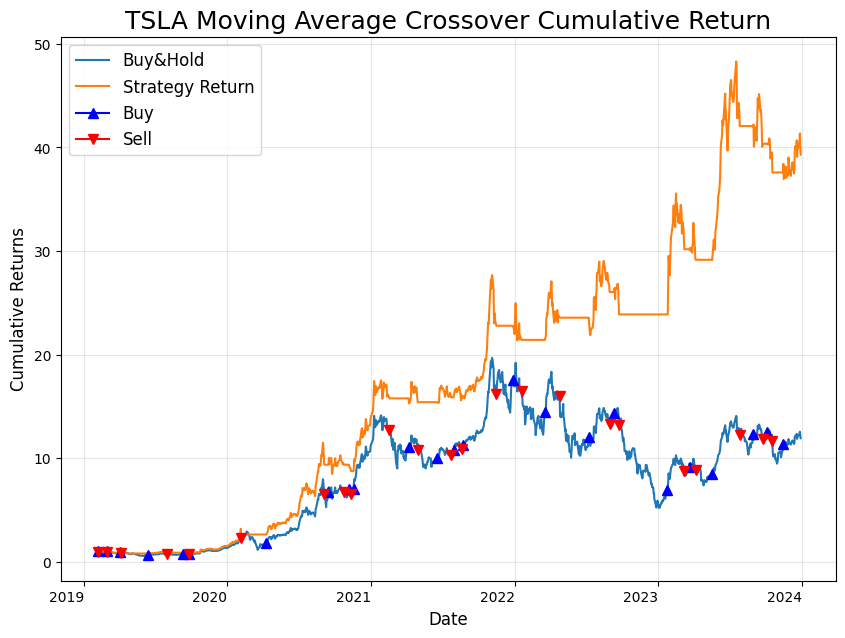

In [40]:
buy_and_hold = data['Close']/data['Close'].iloc[0]
buy_price = data['Buy_Price']/data['Close'].iloc[0]
sell_price = data['Sell_Price']/data['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
data['Cumulative_Return'].plot(ax=ax, label='Strategy Return')
buy_price.plot(ax=ax, label='Buy', marker='^', color='b', markersize=7)
sell_price.plot(ax=ax, label='Sell', marker='v', color='r', markersize=7)

ax.set_title(f'{ticker} Moving Average Crossover Cumulative Return', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.show()

## 6.4 전략 검증

In [41]:
ticker = 'TSLA'
start_date = '2017-07-01'
end_date = '2022-07-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


In [42]:
optimal_params, optimal_df = parameter_optimizer3(df)

Max Tuples:[(7, 20, 0.17, np.float64(10.243115612617501))]
Optimal Parameters:(7, 20, np.float64(0.17)), Optimized Return:1024.31%


In [43]:
ticker = 'TSLA'
start_date = '2022-06-05'
end_date = '2024-07-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


In [44]:
data, ret = mac_strategy3(df, 7, 20, 0.17)

Final cumulative return of the strategy: 40.81%


In [45]:
tear_sheet3(data)

Trading Period:2.0 years
Final cumulative return of the strategy:40.81%, Buy&Hold:-14.78%
Strategy CAGR:18.87%, Benchmark CAGR:-7.76%
Sharpe Ratio: 0.66
Strategy MDD: -39.35%, Benchmark MDD: -65.05%
Number of Profitable Trades:3, Number of Loss Trades:7, Win Rate:30.00%
Average Holding Period:24.0days
Avg ROR/trade in profitable trades:0.280%, Avg ROR/trade in loss trades:-0.063%
Profit/Loss Ratio: 4.41


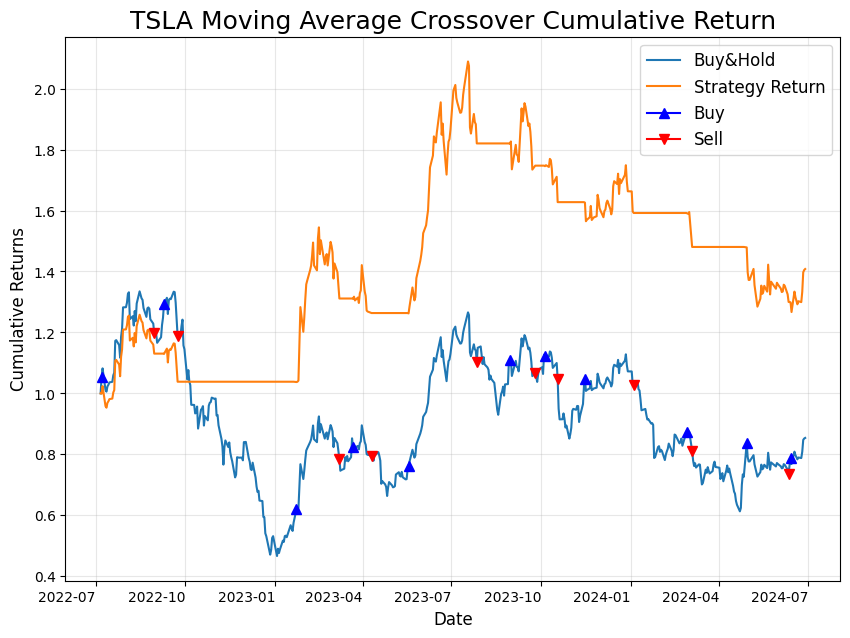

In [46]:
buy_and_hold = data['Close']/data['Close'].iloc[0]
buy_price = data['Buy_Price']/data['Close'].iloc[0]
sell_price = data['Sell_Price']/data['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
data['Cumulative_Return'].plot(ax=ax, label='Strategy Return')
buy_price.plot(ax=ax, label='Buy', marker='^', color='b', markersize=7)
sell_price.plot(ax=ax, label='Sell', marker='v', color='r', markersize=7)

ax.set_title(f'{ticker} Moving Average Crossover Cumulative Return', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.show()

### 코드 6-19 MAC 전략의 Rolling Test 함수

In [47]:
from datetime import datetime
def rolling_test(ticker, date):
    # 데이터 다운로드
    middle_date = date
    middle_date_dt = datetime.strptime(middle_date, '%Y-%m-%d')
    start_date_dt = middle_date_dt.replace(year=middle_date_dt.year - 5)
    start_date = start_date_dt.strftime('%Y-%m-%d')   
    end_date_dt = middle_date_dt.replace(year=middle_date_dt.year + 2)
    end_date = end_date_dt.strftime('%Y-%m-%d')
    df = yf.download(ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)

    # 파라미터 최적화와 백테스트
    df_train = df.loc[start_date:middle_date].copy()
    optimal_params, optimal_df = parameter_optimizer3(df_train)   
    df_test = df.loc[middle_date:].copy()
    data, ret = mac_strategy3(df_test, optimal_params[0], optimal_params[1], \
                               optimal_params[2])

    # 연평균 성장률 CAGR
    fee_rate = 0.001
    trading_period = len(data)/252 # in years   
    buy_and_hold = data['Close'].iloc[-1]*(1-fee_rate)\
    /(data['Close'].iloc[0]*(1+fee_rate))
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold)**(1/trading_period)-1

    # 최대 낙폭 Maximum Drawdown
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    mdd_strategy = data['Drawdown'].min()

    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min()  

    return CAGR_strategy, mdd_strategy, CAGR_benchmark, mdd_benchmark

### 코드 6-20 과거 5년간 6개월 단위 Rolling Test

In [50]:
dates = ['2018-01-01','2018-07-01','2019-01-01','2019-07-01','2020-01-01',\
         '2020-07-01','2021-01-01','2021-07-01','2022-01-01','2022-07-01']
results = \
{('Strategy','CAGR'):[],('Strategy','MDD'):[],('Benchmark','CAGR'):[],\
           ('Benchmark','MDD'):[]}
ticker = 'TSLA'
# ticker = 'TQQQ'
for date in dates:
    CAGR_strategy, mdd_strategy, CAGR_benchmark, mdd_benchmark = \
    rolling_test(ticker, date)
    results[('Strategy','CAGR')].append(CAGR_strategy)
    results[('Strategy','MDD')].append(mdd_strategy)
    results[('Benchmark','CAGR')].append(CAGR_benchmark)
    results[('Benchmark','MDD')].append(mdd_benchmark)
    print(f'Date:{date}, CAGR_Strategy:{100*CAGR_strategy:.2f}%, '
          f'MDD_Strategy:{100*mdd_strategy:.2f}% CAGR_Benchmark:'
        f'{100*CAGR_benchmark:.2f}%, MDD_Benchmark:{100*mdd_benchmark:.2f}%')
results_df = pd.DataFrame(results, index=dates)
results_df

[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(15, 20, 0.19, np.float64(6.614145478446137))]
Optimal Parameters:(15, 20, np.float64(0.19)), Optimized Return:661.41%
Final cumulative return of the strategy: 7.94%
Date:2018-01-01, CAGR_Strategy:4.07%, MDD_Strategy:-43.21% CAGR_Benchmark:8.94%, MDD_Benchmark:-52.85%


[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(15, 28, 0.11, np.float64(0.9345583549634973))]
Optimal Parameters:(15, 28, np.float64(0.11)), Optimized Return:93.46%
Final cumulative return of the strategy: 154.46%
Date:2018-07-01, CAGR_Strategy:64.13%, MDD_Strategy:-28.98% CAGR_Benchmark:80.11%, MDD_Benchmark:-60.63%


[*********************100%%**********************]  1 of 1 completed


...

[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(8, 22, 0.17, np.float64(13.804886272971448))]
Optimal Parameters:(8, 22, np.float64(0.17)), Optimized Return:1380.49%
Final cumulative return of the strategy: 43.66%
Date:2022-01-01, CAGR_Strategy:21.00%, MDD_Strategy:-28.75% CAGR_Benchmark:-9.06%, MDD_Benchmark:-71.69%


[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(7, 20, 0.17, np.float64(10.243115612617501))]
Optimal Parameters:(7, 20, np.float64(0.17)), Optimized Return:1024.31%
Final cumulative return of the strategy: 23.83%
Date:2022-07-01, CAGR_Strategy:11.85%, MDD_Strategy:-39.25% CAGR_Benchmark:-19.29%, MDD_Benchmark:-65.05%


Strategy           Benchmark          
                CAGR       MDD      CAGR       MDD
2018-01-01  0.040665 -0.432091  0.089388 -0.528493
2018-07-01  0.641313 -0.289841  0.801062 -0.606265
2019-01-01  1.174842 -0.257206  2.599176 -0.606265
2019-07-01  1.016941 -0.244779  3.036363 -0.606265
2020-01-01  0.578185 -0.232313  1.754760 -0.536184
2020-07-01  0.423210 -0.288967  0.304891 -0.489263
2021-01-01  0.099110 -0.288033 -0.313705 -0.733883
2021-07-01  0.239392 -0.285950  0.053335 -0.736322
2022-01-01  0.209981 -0.287530 -0.090604 -0.716880
2022-07-01  0.118502 -0.392455 -0.192878 -0.650524

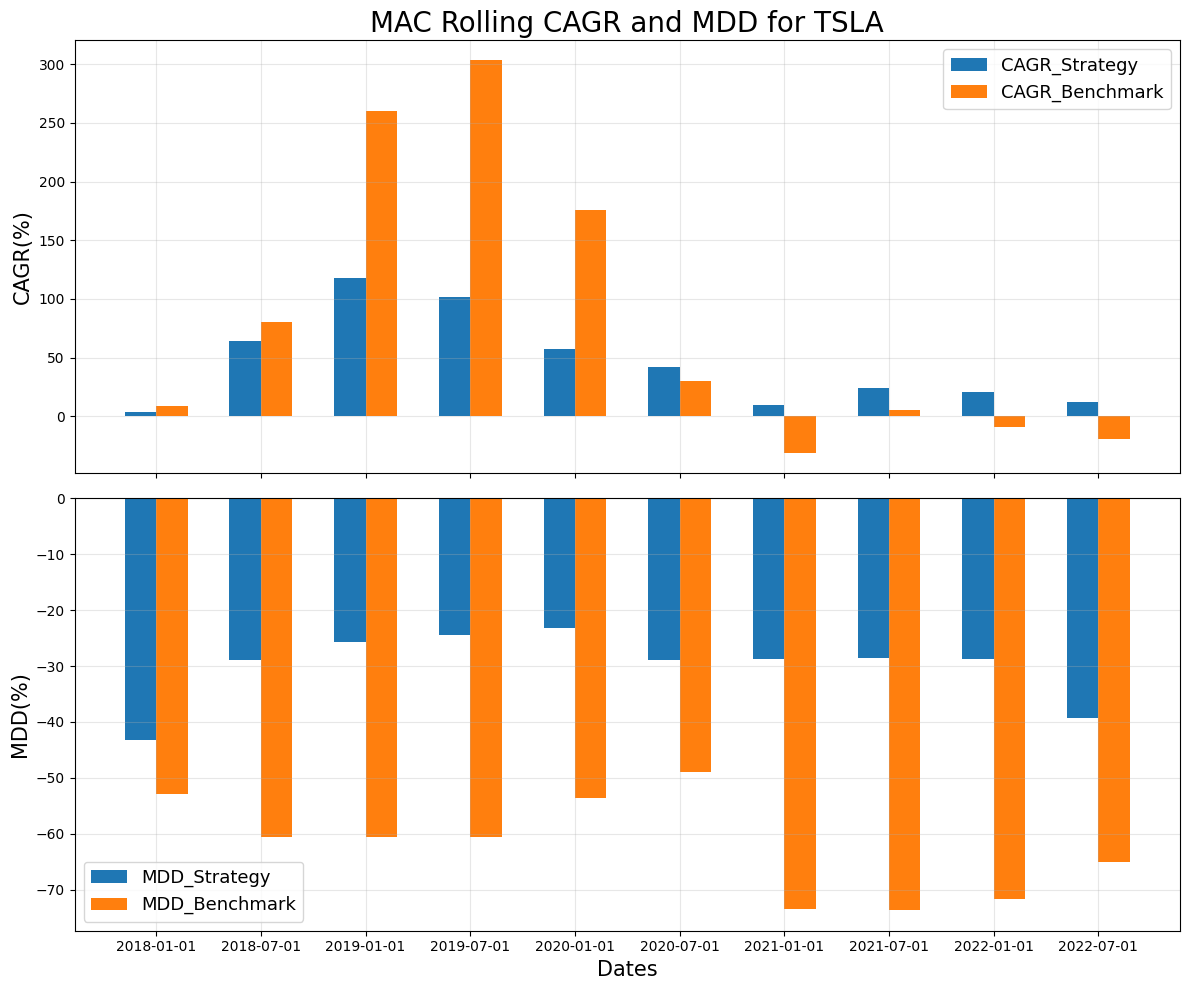

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Data
values1 = results_df[('Strategy','CAGR')].values
values2 = results_df[('Benchmark','CAGR')].values
values3 = results_df[('Strategy','MDD')].values
values4 = results_df[('Benchmark','MDD')].values

# Define the position of bars on x-axis
bar_width = 0.3
index = np.arange(len(dates))

# Create figure and axes with figsize
fig, ax = plt.subplots(2,1, figsize=(12, 10), sharex=True)

# Create grouped bar graph
ax[0].bar(index, values1*100, bar_width, label='CAGR_Strategy')
ax[0].bar(index + bar_width, values2*100, bar_width, label='CAGR_Benchmark')

ax[1].bar(index, values3*100, bar_width, label='MDD_Strategy')
ax[1].bar(index + bar_width, values4*100, bar_width, label='MDD_Benchmark')

# Add labels, title, and ticks
ax[0].set_ylabel('CAGR(%)', fontsize=15)
ax[0].set_title(f'MAC Rolling CAGR and MDD for {ticker}', fontsize=20)

ax[1].set_ylabel('MDD(%)', fontsize=15)
ax[1].set_xlabel('Dates', fontsize=15)
ax[1].set_xticks(index + bar_width / 2)
ax[1].set_xticklabels(dates)
ax[0].legend(fontsize=13)
ax[1].legend(fontsize=13)
ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()